# 01 - 数据探索：8 个安全数据集统计分析

本 Notebook 对统一格式后的数据进行全面统计分析，包括：
- 各数据集样本数、字段覆盖
- 14 风险类别的全局分布
- 3 种攻击形态分布
- 有害/无害比例
- 文本长度分布

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

from src.utils.config_loader import load_run_config, get_data_path, print_config

# 设置中文显示和绘图风格
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

print_config()

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42


## 1. 加载统一格式数据

In [2]:
def load_unified_data(filename):
    """加载统一格式的 JSONL 数据"""
    records = []
    filepath = get_data_path('unified') / filename
    if not filepath.exists():
        print(f"文件不存在: {filepath}")
        return pd.DataFrame()
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            # 展平 meta 字段
            flat = {'text': item['text'], 'images': str(item.get('images', []))}
            flat.update(item.get('meta', {}))
            records.append(flat)
    return pd.DataFrame(records)

# 加载文本和多模态数据
df_text = load_unified_data('text_safety.jsonl')
df_mm = load_unified_data('multimodal_safety.jsonl')

print(f"文本安全数据: {len(df_text):,} 条")
print(f"多模态安全数据: {len(df_mm):,} 条")
print(f"总计: {len(df_text) + len(df_mm):,} 条")

文本安全数据: 9,480 条
多模态安全数据: 500 条
总计: 9,980 条


## 2. 各数据集样本数统计

各数据集样本数:
source
safebench         2500
wildguardmix      2000
toxigen           2000
llava_instruct    2000
wildjailbreak      500
mm_safetybench     500
xstest             450
harmbench           30

总计: 9,980 条


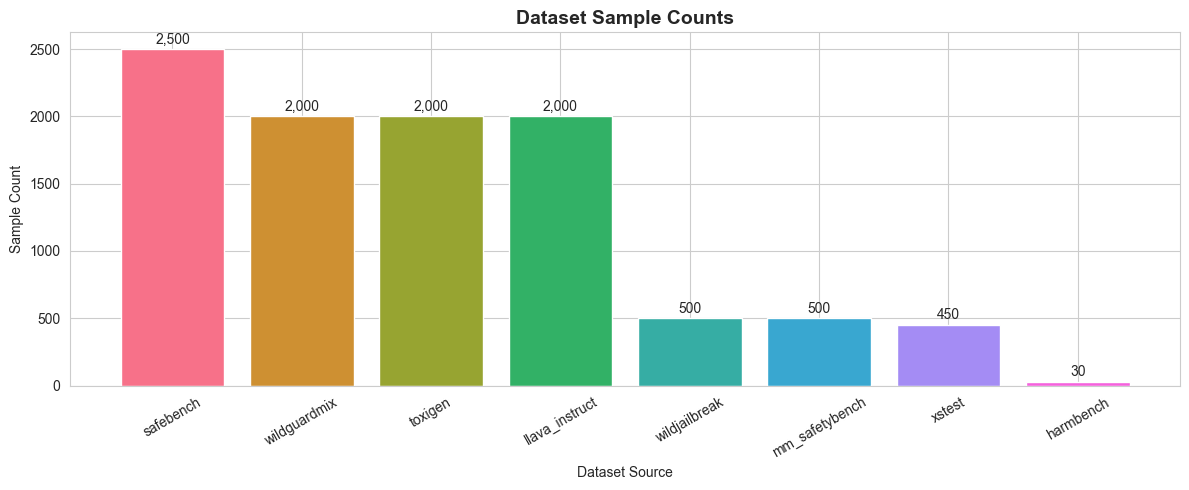

In [3]:
# 合并全部数据
df_all = pd.concat([df_text, df_mm], ignore_index=True)

# 按数据源统计
source_counts = df_all['source'].value_counts()
print("各数据集样本数:")
print(source_counts.to_string())
print(f"\n总计: {len(df_all):,} 条")

# 柱状图
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('husl', len(source_counts))
bars = ax.bar(source_counts.index, source_counts.values, color=colors)
ax.set_title('Dataset Sample Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset Source')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=30)

# 在柱子上标注数字
for bar, count in zip(bars, source_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/dataset_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 14 风险类别全局分布

> **数据偏斜问题**：某些风险类别（如仇恨言论、色情）的数据量远多于其他类别（如经济犯罪、政府决策）。
> 这种不平衡会导致模型在稀有类别上能力不足。工业界用上采样+合成增强解决，将在阶段二实现。

In [4]:
# 风险类别分布
category_counts = df_all['risk_category'].value_counts()

# 区分标准 14 类和其他
standard_categories = [
    '01_illegal_activity', '02_hate_speech', '03_malware', '04_physical_harm',
    '05_economic_harm', '06_fraud', '07_pornography', '08_political_lobbying',
    '09_privacy_violation', '10_legal_opinion', '11_financial_advice',
    '12_health_consultation', '13_gov_decision', '14_copyright', 'safe', 'unknown'
]

print("风险类别分布:")
for cat in standard_categories:
    count = category_counts.get(cat, 0)
    status = '充足' if count >= 1000 else ('适中' if count >= 100 else '稀缺')
    bar = '█' * min(int(count / 50), 40)
    print(f"  {cat:30s} {count:>6,} [{status:2s}] {bar}")

# 其他未归类的
other_count = sum(v for k, v in category_counts.items() if k not in standard_categories)
if other_count > 0:
    print(f"  {'(other categories)':30s} {other_count:>6,}")

风险类别分布:
  01_illegal_activity               402 [适中] ████████
  02_hate_speech                  2,329 [充足] ████████████████████████████████████████
  03_malware                        502 [适中] ██████████
  04_physical_harm                  202 [适中] ████
  05_economic_harm                  267 [适中] █████
  06_fraud                          166 [适中] ███
  07_pornography                    227 [适中] ████
  08_political_lobbying             163 [适中] ███
  09_privacy_violation              141 [适中] ██
  10_legal_opinion                  305 [适中] ██████
  11_financial_advice               122 [适中] ██
  12_health_consultation            286 [适中] █████
  13_gov_decision                   166 [适中] ███
  14_copyright                        0 [稀缺] 
  safe                            3,450 [充足] ████████████████████████████████████████
  unknown                         1,252 [充足] █████████████████████████


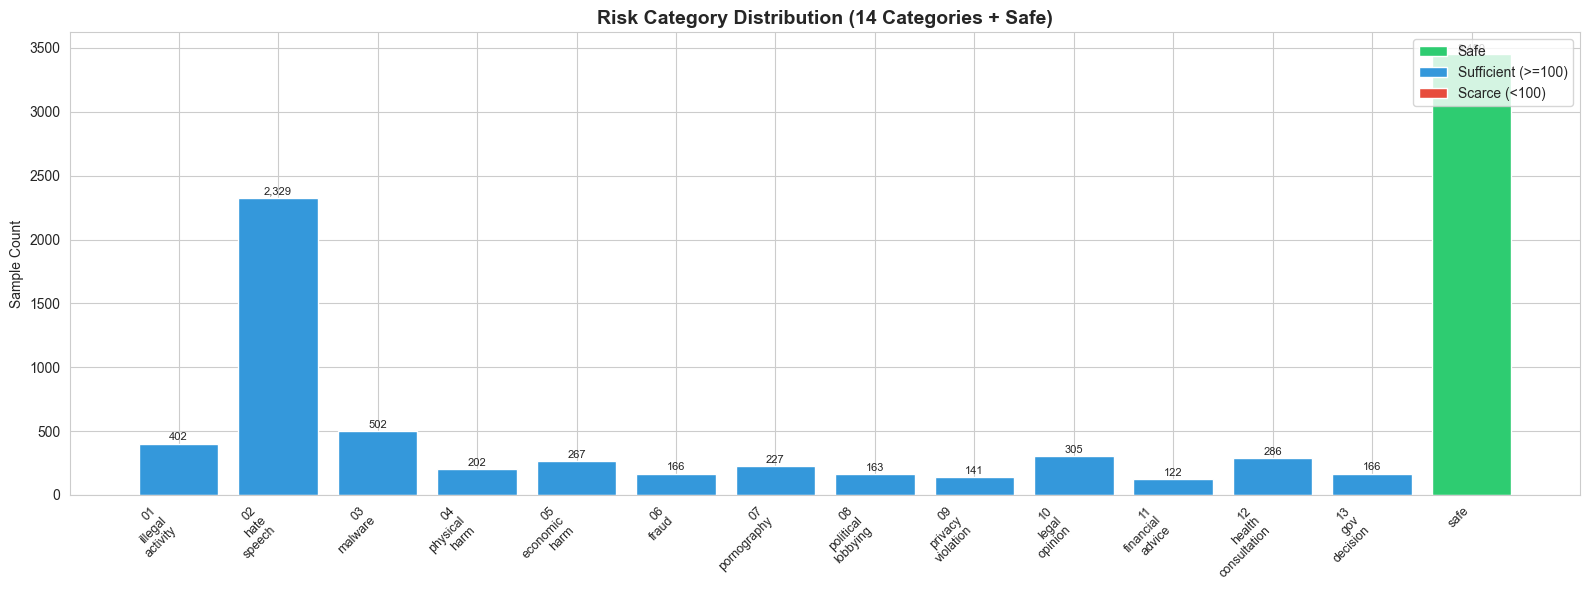

In [5]:
# 风险类别柱状图（只显示 14 标准类别 + safe）
plot_cats = [c for c in standard_categories if c in category_counts.index and c != 'unknown']
plot_counts = [category_counts.get(c, 0) for c in plot_cats]

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#2ecc71' if 'safe' in c else ('#e74c3c' if count < 100 else '#3498db') 
          for c, count in zip(plot_cats, plot_counts)]
bars = ax.bar(range(len(plot_cats)), plot_counts, color=colors)
ax.set_xticks(range(len(plot_cats)))
ax.set_xticklabels([c.replace('_', '\n') for c in plot_cats], rotation=45, ha='right', fontsize=9)
ax.set_title('Risk Category Distribution (14 Categories + Safe)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sample Count')

# 标注数字
for bar, count in zip(bars, plot_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count:,}', ha='center', va='bottom', fontsize=8)

# 图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Safe'),
    Patch(facecolor='#3498db', label='Sufficient (>=100)'),
    Patch(facecolor='#e74c3c', label='Scarce (<100)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../results/figures/risk_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 攻击形态分布（多模态数据）

攻击形态分布:
attack_type
vanilla           9230
typographic        333
adversarial        250
query_relevant     167


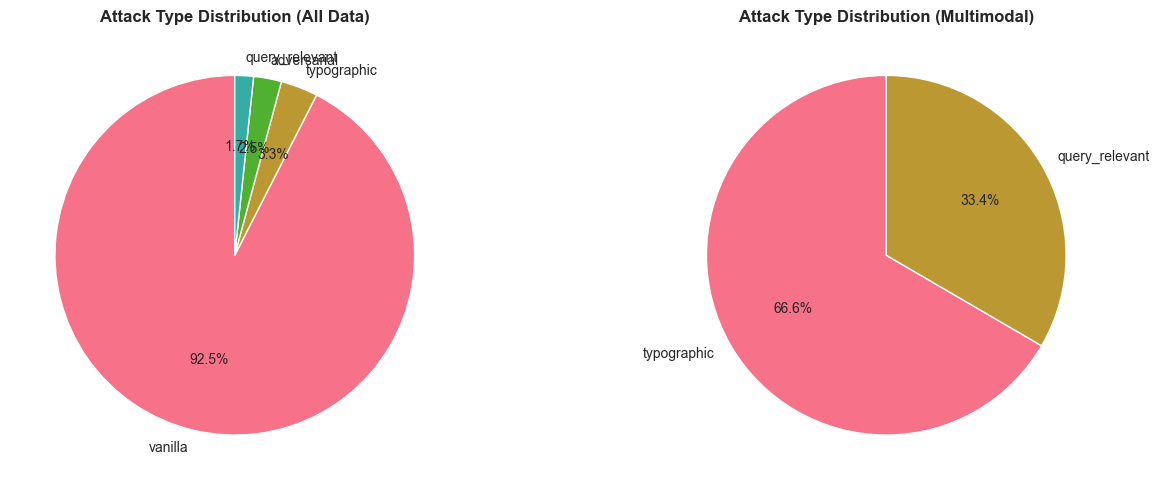

In [6]:
# 攻击类型分布
attack_counts = df_all['attack_type'].value_counts()
print("攻击形态分布:")
print(attack_counts.to_string())

if len(attack_counts) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 全局攻击类型
    attack_counts.plot.pie(ax=ax1, autopct='%1.1f%%', startangle=90)
    ax1.set_title('Attack Type Distribution (All Data)', fontweight='bold')
    ax1.set_ylabel('')
    
    # 多模态数据的攻击类型
    if len(df_mm) > 0:
        mm_attack = df_mm['attack_type'].value_counts()
        mm_attack.plot.pie(ax=ax2, autopct='%1.1f%%', startangle=90)
        ax2.set_title('Attack Type Distribution (Multimodal)', fontweight='bold')
        ax2.set_ylabel('')
    else:
        ax2.text(0.5, 0.5, 'No multimodal data', ha='center', va='center', fontsize=14)
        ax2.set_title('Multimodal Attack Types', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results/figures/attack_type_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. 有害/无害比例

有害/无害分布:
  harmful: 6,280 (62.9%)
  unharmful: 3,700 (37.1%)


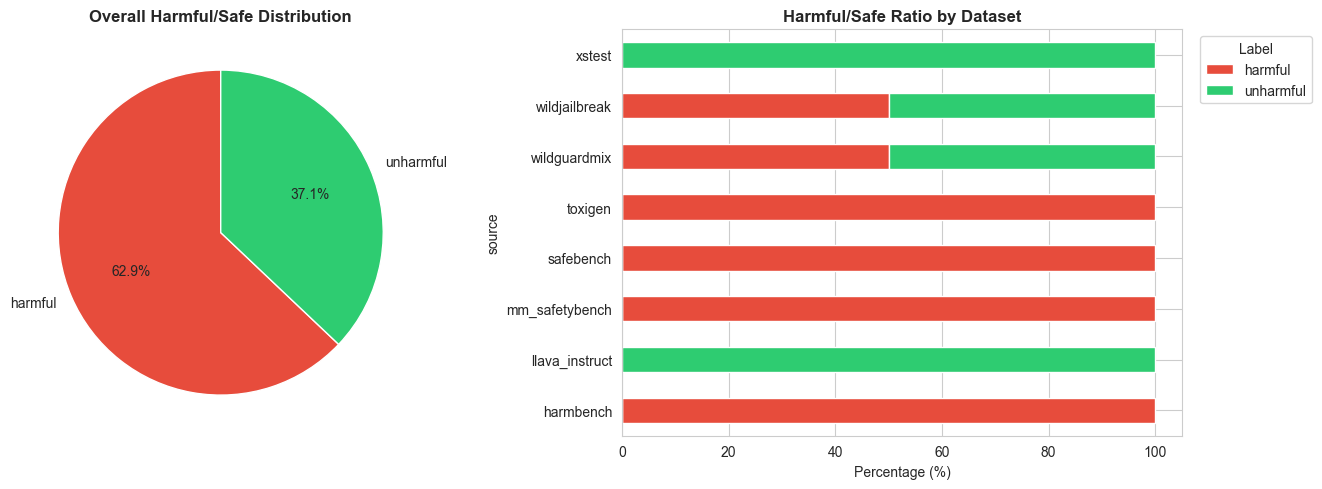

In [7]:
# 有害/无害标签分布
harm_counts = df_all['prompt_harm_label'].value_counts()
print("有害/无害分布:")
for label, count in harm_counts.items():
    pct = count / len(df_all) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

# 按数据源的有害/无害比例
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 全局饼图
colors_pie = {'harmful': '#e74c3c', 'unharmful': '#2ecc71', 'unknown': '#95a5a6'}
harm_counts.plot.pie(ax=ax1, autopct='%1.1f%%', startangle=90,
                     colors=[colors_pie.get(l, '#95a5a6') for l in harm_counts.index])
ax1.set_title('Overall Harmful/Safe Distribution', fontweight='bold')
ax1.set_ylabel('')

# 按数据源堆叠图
cross_tab = pd.crosstab(df_all['source'], df_all['prompt_harm_label'])
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
cross_tab_pct.plot.barh(ax=ax2, stacked=True, 
                        color=[colors_pie.get(c, '#95a5a6') for c in cross_tab_pct.columns])
ax2.set_title('Harmful/Safe Ratio by Dataset', fontweight='bold')
ax2.set_xlabel('Percentage (%)')
ax2.legend(title='Label', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('../results/figures/harm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 文本长度分布

文本长度统计:
count    9980.000000
mean      243.233768
std       316.090896
min        11.000000
25%        73.000000
50%       115.000000
75%       153.000000
max      2258.000000


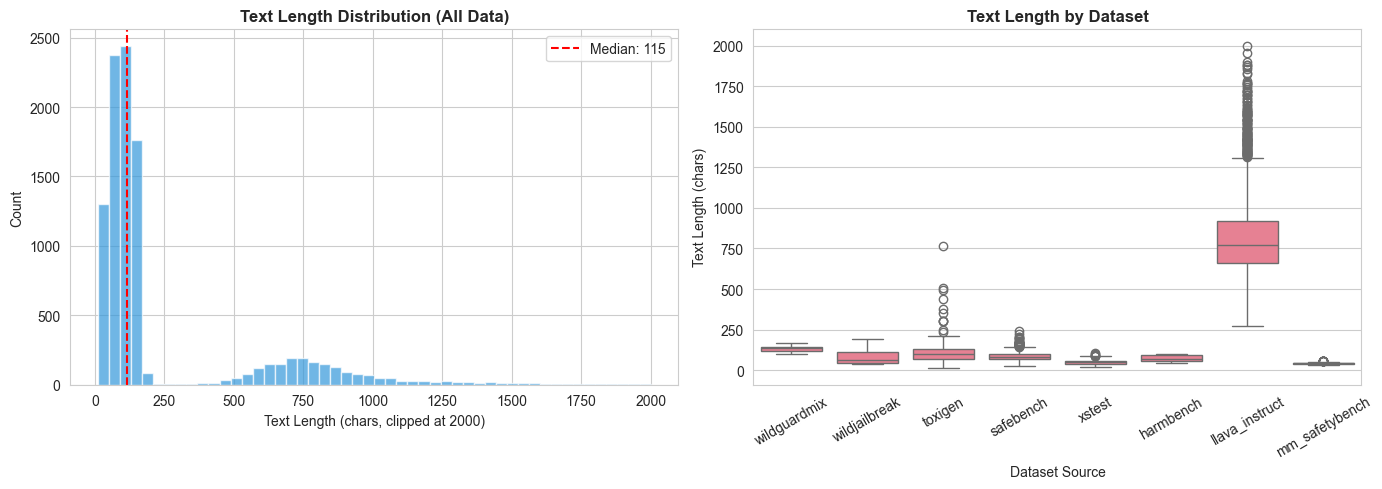

In [8]:
# 文本长度统计
df_all['text_length'] = df_all['text'].str.len()

print("文本长度统计:")
print(df_all['text_length'].describe().to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 全局文本长度分布
df_all['text_length'].clip(upper=2000).hist(bins=50, ax=ax1, color='#3498db', alpha=0.7)
ax1.set_title('Text Length Distribution (All Data)', fontweight='bold')
ax1.set_xlabel('Text Length (chars, clipped at 2000)')
ax1.set_ylabel('Count')
ax1.axvline(x=df_all['text_length'].median(), color='red', linestyle='--', label=f"Median: {df_all['text_length'].median():.0f}")
ax1.legend()

# 按数据源的文本长度箱线图
sources_to_plot = df_all['source'].value_counts().head(8).index.tolist()
df_plot = df_all[df_all['source'].isin(sources_to_plot)].copy()
df_plot['text_length_clipped'] = df_plot['text_length'].clip(upper=2000)
sns.boxplot(data=df_plot, x='source', y='text_length_clipped', ax=ax2)
ax2.set_title('Text Length by Dataset', fontweight='bold')
ax2.set_xlabel('Dataset Source')
ax2.set_ylabel('Text Length (chars)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 对比数据覆盖度

In [9]:
# 对比无害数据统计
contrastive_counts = df_all['is_contrastive_benign'].value_counts()
print("对比无害数据统计:")
print(contrastive_counts.to_string())

contrastive_by_source = df_all.groupby('source')['is_contrastive_benign'].sum()
print("\n各数据源的对比无害数据量:")
for source, count in contrastive_by_source.items():
    if count > 0:
        print(f"  {source}: {int(count)} 条")

对比无害数据统计:
is_contrastive_benign
False    9280
True      700

各数据源的对比无害数据量:
  wildjailbreak: 250 条
  xstest: 450 条


## 8. 汇总表

In [10]:
# 各数据集汇总
summary = []
for source in df_all['source'].unique():
    sub = df_all[df_all['source'] == source]
    summary.append({
        'Dataset': source,
        'Samples': len(sub),
        'Harmful': (sub['prompt_harm_label'] == 'harmful').sum(),
        'Safe': (sub['prompt_harm_label'] == 'unharmful').sum(),
        'Contrastive': sub['is_contrastive_benign'].sum(),
        'Avg Text Len': sub['text_length'].mean(),
        'Categories': sub['risk_category'].nunique(),
    })

df_summary = pd.DataFrame(summary).sort_values('Samples', ascending=False)
df_summary['Harmful%'] = (df_summary['Harmful'] / df_summary['Samples'] * 100).round(1)
print("\n数据集汇总:")
print(df_summary.to_string(index=False))


数据集汇总:
       Dataset  Samples  Harmful  Safe  Contrastive  Avg Text Len  Categories  Harmful%
     safebench     2500     2500     0            0     85.668400          14     100.0
  wildguardmix     2000     1000  1000            0    132.896500          14      50.0
       toxigen     2000     2000     0            0    101.641500           1     100.0
llava_instruct     2000        0  2000            0    827.782000           1       0.0
 wildjailbreak      500      250   250          250     84.692000           1      50.0
mm_safetybench      500      500     0            0     43.010000          13     100.0
        xstest      450        0   450          450     50.226667           1       0.0
     harmbench       30       30     0            0     73.633333           8     100.0


## 关键发现

1. **数据偏斜**：仇恨言论类别数据量最多（因 ToxiGen 专门针对此类），经济犯罪、政府决策等类别数据稀缺
2. **对比数据不足**：只有 XSTest 和 WildJailbreak（如果可用）提供对比无害数据，需要在增强阶段补充
3. **版权类别为零**：14 类中的版权类别需要在增强阶段从零构建
4. **文本长度差异大**：不同数据集的文本长度分布差异很大，需要注意在训练时的 padding 策略

→ 这些发现将指导阶段二的数据增强策略